# Разработка A/B-тестирования и анализ результатов

Вы работаете в компании развлекательного приложения с «бесконечной» лентой коротких видео. Основная цель продукта — удерживать внимание пользователя.

Монетизация приложения строится на двух моделях доступа к видео:

* Рекламная модель — бесплатный доступ к контенту, доход приносят рекламные ролики, встроенные в ленту.
* Подписочная модель — ежемесячная оплата, которая полностью отключает рекламу и делает просмотр беспрерывным.
Главный двигатель вашего приложения — это алгоритм рекомендаций.


>Рекомендательная система — это алгоритм, который из миллионов доступных вариантов выбирает те, которые с наибольшей вероятностью понравятся конкретному пользователю.
>Если алгоритм в приложении для коротких видео будет работать плохо (то есть будет отбирать неинтересный контент), пользователь быстро его закроет. Если хорошо — это создаст для пользователя стимул остаться в приложении дольше, что напрямую влияет на выручку компании.


До недавнего времени лента формировалась на основе простых эвристик, по схеме «популярное за день + новинки». Сейчас всё меняется: команда Data Science разработала новый алгоритм ранжирования контента.

В отличие от текущей системы, модель МО учитывает персональные интересы пользователя: его прошлые отметки «Нравится» и длительность просмотра. Модель оптимизирована на предсказание вероятности глубокого вовлечения (просмотр более 80% видео). Таким образом, более релевантный контент должен увеличивать время пользователей в приложении. Однако есть два риска, которые могут негативно повлиять на доходы:

1. Пользователи без подписки, максимально поглощённые релевантным контентом, могут начать негативно реагировать на рекламные вставки.
2. Ценность платной подписки «без рекламы» снизится, если контент станет слишком поглощающим.


## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### Импорт необходимых библиотек и методов

В этой ячейке импортируйте все необходимые библиотеки и функции, которые понадобятся нам для проведения A/B-теста и расчётов.

Обратите внимание: часть импортов вам нужно будет дополнить самостоятельно.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Импорт инструментов для расчёта мощности теста и эффекта
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

from math import ceil

In [2]:
# настройки визуалиции 
plt.rcParams["figure.figsize"] = (12, 8)

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [3]:
sessions_history = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_history.csv')
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [4]:
users_sessions = sessions_history.groupby('user_id')['session_id'].nunique()
max_user_sessions = users_sessions.idxmax()
max_user_sessions_df = sessions_history[sessions_history['user_id'] == max_user_sessions]
max_user_sessions_df.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android


#### Преобразование типов

In [5]:
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])
sessions_history['install_date'] = pd.to_datetime(sessions_history['install_date'])

#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

- Проанализируйте результаты этого этапа работы.


In [6]:
unique_users_by_date = sessions_history.groupby('session_date')['user_id'].nunique().reset_index(name='n_users')
active_users_by_date = (
	sessions_history[sessions_history['registration_flag'] == 1].groupby('session_date')['user_id'].nunique().reset_index(name='n_reg')
)

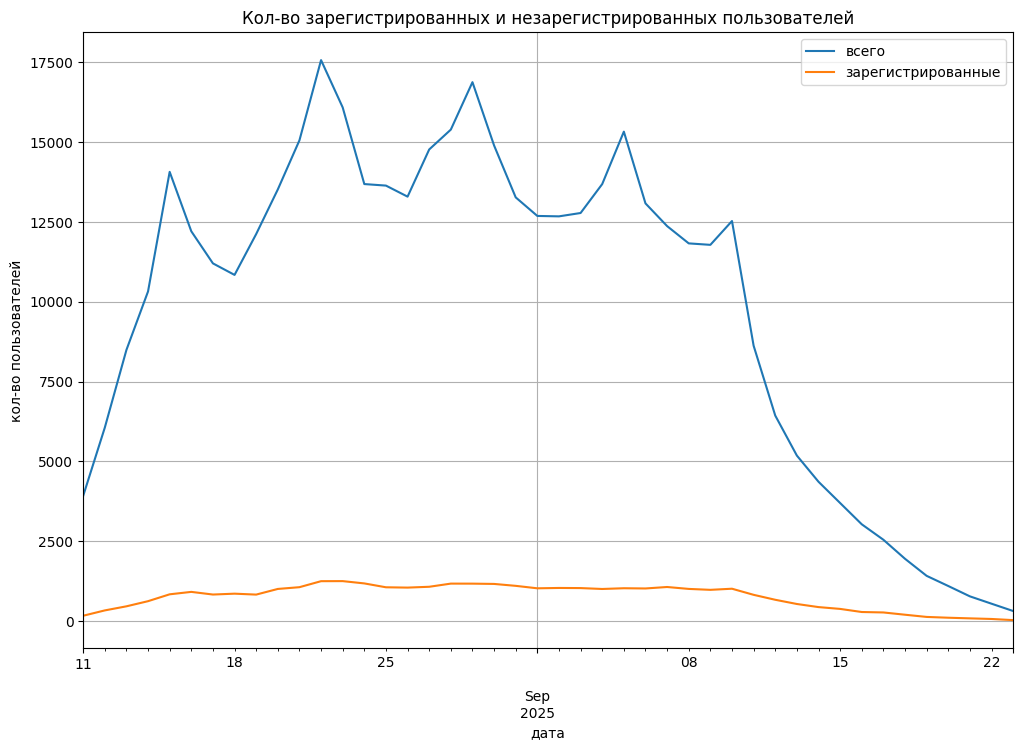

In [7]:
ax = unique_users_by_date.plot(kind='line', x='session_date', y='n_users', label='всего')
active_users_by_date.plot(kind='line', x='session_date', y='n_reg', label='зарегистрированные', grid=True, ax=ax)

plt.title('Кол-во зарегистрированных и незарегистрированных пользователей')
plt.xlabel('дата')
plt.ylabel('кол-во пользователей')
plt.legend()
plt.show()

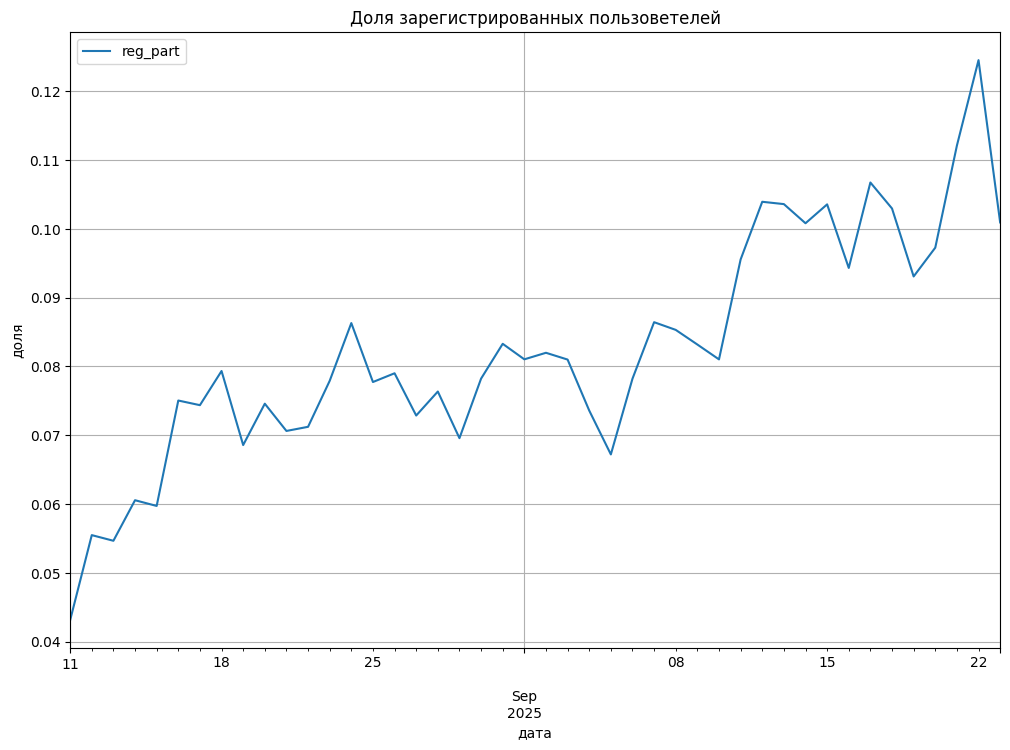

In [8]:
users_merged = pd.merge(left=unique_users_by_date, right=active_users_by_date, how='left', on='session_date')
users_merged['reg_part'] = users_merged['n_reg'] / users_merged['n_users']

users_merged.plot(kind='line', x='session_date', y='reg_part', grid=True)
plt.title('Доля зарегистрированных пользоветелей')
plt.xlabel('дата')
plt.ylabel('доля')
plt.show()

Анализ:
- доля зарегистрированных пользователей имеет тренд на рост

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

- Проанализируйте результаты этого этапа работы.


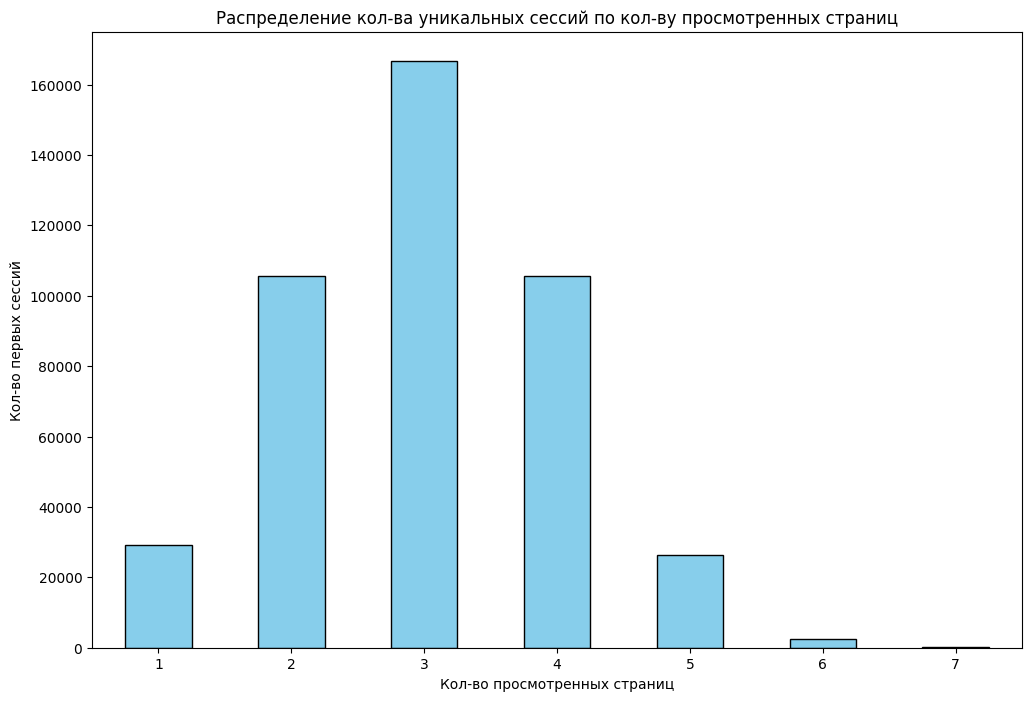

In [11]:
first_sessions = sessions_history.groupby(['session_date', 'user_id']).first().reset_index()

first_sessions_page_counter = first_sessions.groupby('page_counter')['session_id'].count().reset_index(name='n_first_sessions')

first_sessions_page_counter.plot.bar(
    x='page_counter', y='n_first_sessions', color='skyblue', edgecolor='black', legend=False
)
plt.xlabel('Кол-во просмотренных страниц')
plt.ylabel('Кол-во первых сессий')
plt.title('Распределение кол-ва уникальных сессий по кол-ву просмотренных страниц')
plt.xticks(rotation=0) 

plt.show()

Анализ:
- наиболее часто среди первых сессий встречается 3 просмотра страниц. 
- более 7ми страниц не встречается
- подавляющее большинство пользователей просматривают от 1 до 5 страниц. 6-7 довольно редко
- по форме распределение симметричное относительно 3х просмотров

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

- Проанализируйте результаты этого этапа работы.


In [12]:
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)
first_sessions = sessions_history.groupby(['session_date', 'user_id']).first().reset_index() # первые сессии

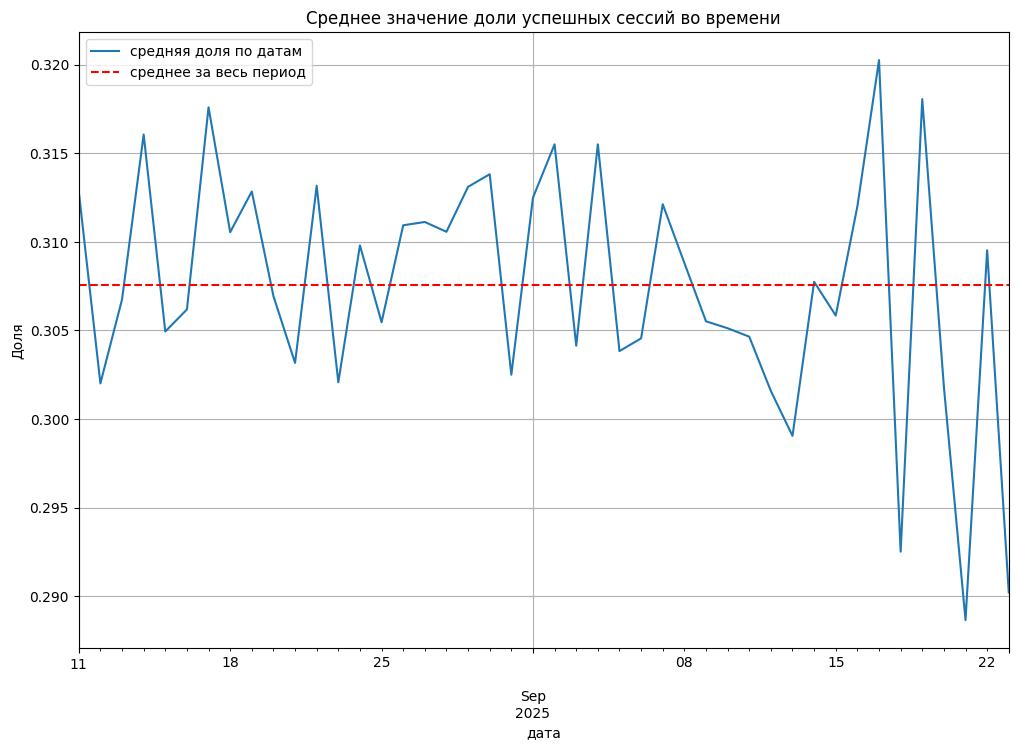

In [ ]:
success_first_sessions = first_sessions.groupby('session_date')['good_session'].mean().reset_index(name='success_first_sessions_part')
success_first_sessions.plot(kind='line', x='session_date', y='success_first_sessions_part', label='средняя доля по датам')

success_first_sessions_mean = success_first_sessions['success_first_sessions_part'].mean()
success_first_sessions_std = success_first_sessions['success_first_sessions_part'].std()

plt.hlines(
    y=success_first_sessions_mean, 
    xmin=success_first_sessions['session_date'].min(),
    xmax=success_first_sessions['session_date'].max(),
    colors='r',
    linestyles='--',
    label='среднее за весь период'
)

plt.title('Среднее значение доли успешных сессий во времени')
plt.xlabel('дата')
plt.ylabel('Доля')
plt.legend()
plt.grid()
plt.show()

Анализ:
- среднее значение доли успешных сессий варьируется в диапазоне от 0.29 до 0.32
- показатель осциллирует вблизи среденего значения, амплитуда разброса усиливается последнюю неделю 

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [17]:
# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1
)
sample_size

3761.596974012117

#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [20]:
unique_users_by_date.head()

,session_date,n_users
0,2025-08-11,3919
1,2025-08-12,6056
2,2025-08-13,8489
3,2025-08-14,10321
4,2025-08-15,14065


In [22]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = unique_users_by_date['n_users'].mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size * 2 / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 1 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [23]:
sessions_test_part = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test_part.csv')
sessions_test_part.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3130 entries, 0 to 3129
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            3130 non-null   object
 1   session_id         3130 non-null   object
 2   session_date       3130 non-null   object
 3   session_start_ts   3130 non-null   object
 4   install_date       3130 non-null   object
 5   session_number     3130 non-null   int64 
 6   registration_flag  3130 non-null   int64 
 7   page_counter       3130 non-null   int64 
 8   region             3130 non-null   object
 9   device             3130 non-null   object
 10  test_group         3130 non-null   object
dtypes: int64(3), object(8)
memory usage: 269.1+ KB


In [25]:
sessions_test_part['test_group'].unique()

array(['B', 'A'], dtype=object)

In [27]:
# кол-во уникальных пользователей по группам для одного дня наблюдения
n_unique_a = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].nunique()
n_unique_b = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].nunique()
n_unique_a, n_unique_b


(1477, 1466)

Процентная разница A и B: 0.7447528774542992 %


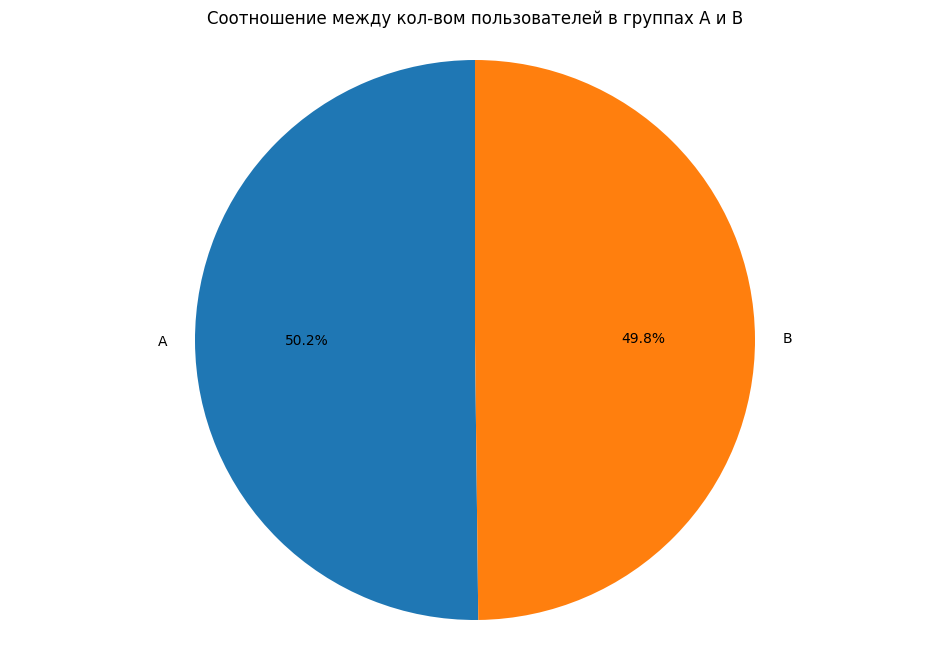

In [30]:
# процентная разница
p_ab_ratio = abs((n_unique_a - n_unique_b) / max(n_unique_a, n_unique_b)) * 100 
print(f'Процентная разница A и B: {p_ab_ratio} %')

plt.pie([n_unique_a, n_unique_b], labels=['A', 'B'], autopct="%1.1f%%", startangle=90)
plt.axis("equal")
plt.title("Соотношение между кол-вом пользователей в группах A и B")
plt.show()


Вывод:
- в группах A и B процентная разница между кол-вом пользователей менее 1%. Проверка распределения пользователей по группам пройдена успешно

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [31]:
unique_users_a = list(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'])
unique_users_b = list(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'])

users_intersection = set(unique_users_a) & set(unique_users_b)
users_intersection

set()

Вывод:
- пересечений нет, разделение по группам корректно. Выборки можно считать независимыми

#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


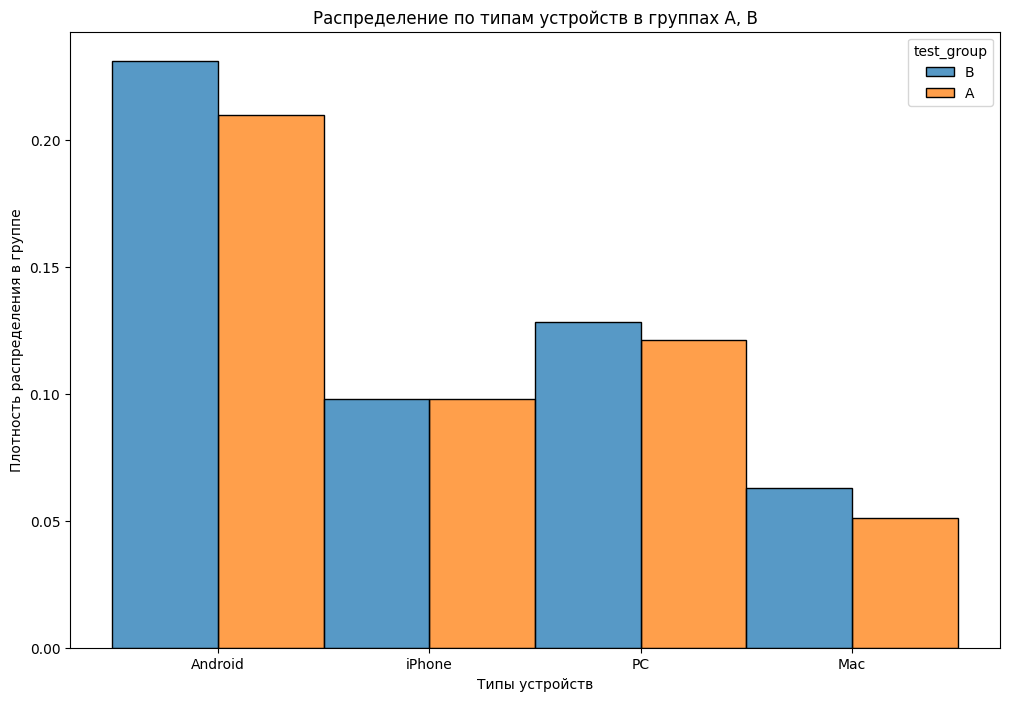

In [47]:
sns.histplot(data=sessions_test_part, x='device', stat='density', hue='test_group', multiple='dodge')
plt.xlabel('Типы устройств')
plt.ylabel('Плотность распределения в группе')
plt.title('Распределение по типам устройств в группах A, B')
plt.show()

Вывод:
- распределения по устройствам среди групп A, B отличаются несущесвтенно. Разделение данных можно считать качественным

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

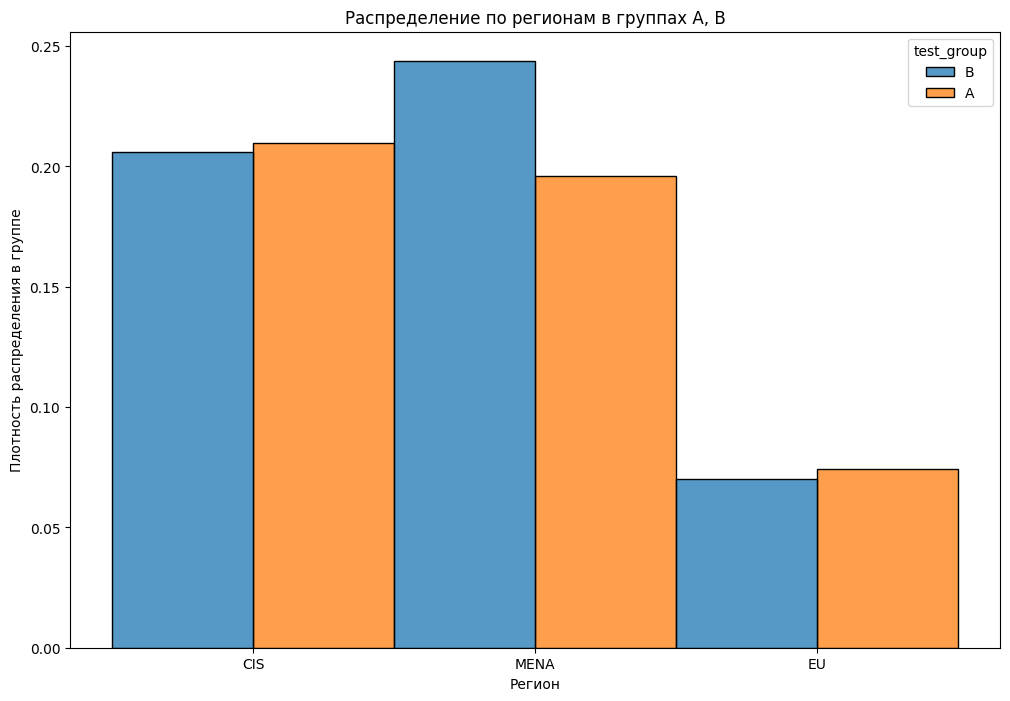

In [51]:
sns.histplot(data=sessions_test_part, x='region', stat='density', hue='test_group', multiple='dodge')
plt.xlabel('Регион')
plt.ylabel('Плотность распределения в группе')
plt.title('Распределение по регионам в группах A, B')
plt.show()

Вывод:
- по доле региона MENA наблюдается различие в 5% между выборками A, B. 
- потенциально это модет сущесвтвенно повлиять на результаты эксперимента


#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

Вывод:
- разделение данных в части кол-ва пользователей корректно: различие менее 1% по уникальным пользователям
- пересечений среди пользователей в группах A,B не обнаружено - можем считать выборки независимыми
- анализ разпределений по категориальным признакам:
	- распределения по устройствам не имеют существенных различий - разбиение корректно
	- распределения по регионам имеют отличие: доля по региону MENA различается на 5% среди групп A,B. Это может оказать влияние на результаты эксперимента. Для более достоверных результатов необходимо более сбалансированные разбиение по этому признаку.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что доля успешных первых сессий для выборок A и B ухудшилась на 0.1%, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.